# Project 3: Advertisement ROI Model

## Applied Data Science 

### Maggie Boles, Adina Kaplan, Logan McCorkle, & Chana Ochs

In [37]:
# import libraries
import numpy as np
import pandas as pd
import sweetviz as sv

# open my CSV
df = pd.read_csv('Advertising_ROI_Cleaned_Final_v2.csv')

# EDA using sweetviz
my_report = sv.analyze(df)

my_report.show_html() 

Done! Use 'show' commands to display/save.   |█████████████████████████████████████████| [100%]   00:02 -> (00:00 left)


Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [51]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Load Data
df = pd.read_csv('bank-additional-full.csv', sep=';')
df['target'] = (df['y'] == 'yes').astype(int)
df = df.drop('y', axis=1)
df = pd.get_dummies(df, drop_first=True)

X = df.drop(['target', 'duration'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Business Parameters (Can be tuned to our specifications)
AVG_PROFIT_PER_SUCCESS = 1000
COST_PER_SECOND = 0.05

# Train & Evaluate Models 
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=400, max_depth=10, 
                                           class_weight='balanced', random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(n_estimators=400, learning_rate=0.08, max_depth=6,
                                subsample=0.8, colsample_bytree=0.8, 
                                scale_pos_weight=len(y_train)/y_train.sum(), random_state=42)
}

print(" MODEL COMPARISON WITH FINANCIAL IMPACT... \n")

for name, model in models.items():
    model.fit(X_train, y_train)
    pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Find best F1 threshold
    thresholds = np.arange(0.05, 0.60, 0.01)
    best_f1 = 0
    best_thresh = 0.5
    for thresh in thresholds:
        f1 = f1_score(y_test, (pred_proba >= thresh).astype(int))
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    
    pred_class = (pred_proba >= best_thresh).astype(int)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, pred_class)
    tn, fp, fn, tp = cm.ravel()
    
    # Financial Impact
    called_contacts = tp + fp
    total_profit = (tp * AVG_PROFIT_PER_SUCCESS) - ((tp + fp) * df['duration'].mean() * COST_PER_SECOND * 10)  # rough estimate
    random_profit = (y_test.mean() * len(y_test) * AVG_PROFIT_PER_SUCCESS) - (len(y_test) * df['duration'].mean() * COST_PER_SECOND * 10)
    
    print(f"\n{name}")
    print("-" * 50)
    print(f"AUC: {roc_auc_score(y_test, pred_proba):.4f} | Best F1: {best_f1:.4f} (thresh={best_thresh:.3f})")
    print(f"Confusion Matrix:")
    print(f"                  Pred No   Pred Yes")
    print(f"Actual No      {tn:6}     {fp:6}")
    print(f"Actual Yes     {fn:6}     {tp:6}")
    print(f"Called Contacts: {called_contacts} | Captured Yes: {tp}")
    print(f"Estimated Campaign Profit: €{total_profit:,.0f}")
    print(f"Profit Lift vs Random Calling: €{total_profit - random_profit:,.0f}")

 MODEL COMPARISON WITH FINANCIAL IMPACT... 


Logistic Regression
--------------------------------------------------
AUC: 0.7993 | Best F1: 0.4875 (thresh=0.590)
Confusion Matrix:
                  Pred No   Pred Yes
Actual No        6457        853
Actual Yes        354        574
Called Contacts: 1427 | Captured Yes: 574
Estimated Campaign Profit: €389,714
Profit Lift vs Random Calling: €525,590

Random Forest
--------------------------------------------------
AUC: 0.8123 | Best F1: 0.5296 (thresh=0.580)
Confusion Matrix:
                  Pred No   Pred Yes
Actual No        6661        649
Actual Yes        360        568
Called Contacts: 1217 | Captured Yes: 568
Estimated Campaign Profit: €410,834
Profit Lift vs Random Calling: €546,710

XGBoost
--------------------------------------------------
AUC: 0.7928 | Best F1: 0.5026 (thresh=0.590)
Confusion Matrix:
                  Pred No   Pred Yes
Actual No        6626        684
Actual Yes        387        541
Called Contacts: 1225 |

In [50]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

print("BANK MARKETING ROI MODEL... \n")

# 1. Load Data 
df = pd.read_csv('bank-additional-full.csv', sep=';')

df['target'] = (df['y'] == 'yes').astype(int)
df = df.drop('y', axis=1)

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

X = df.drop(['target', 'duration'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. TRAIN OPTIMIZED RANDOM FOREST
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
pred_proba = rf.predict_proba(X_test)[:, 1]

# Find best F1 threshold
thresholds = np.arange(0.05, 0.60, 0.01)
best_f1 = 0
best_threshold = 0.5

for thresh in thresholds:
    pred_class = (pred_proba >= thresh).astype(int)
    current_f1 = f1_score(y_test, pred_class)
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = thresh

print(f"Random Forest Performance:")
print(f"AUC:        {roc_auc_score(y_test, pred_proba):.4f}")
print(f"PR-AUC:     {average_precision_score(y_test, pred_proba):.4f}")
print(f"Best F1:    {best_f1:.4f} (threshold = {best_threshold:.3f})\n")

# 3. ROI SCORING 
AVG_PROFIT_PER_SUCCESS = 1000     # ← Change this to your real number
COST_PER_SECOND = 0.05            # ← Change this to your real cost

df['prob_yes'] = rf.predict_proba(X)[:, 1]
df['expected_profit'] = (df['prob_yes'] * AVG_PROFIT_PER_SUCCESS) - (df['duration'] * COST_PER_SECOND)

print(f"Average expected profit per contact: €{df['expected_profit'].mean():.2f}\n")

# 4. TOP 5000 PROFITABLE PROSPECTS
N = 5000

top_5000 = df.nlargest(N, 'expected_profit').copy()

print(f"=== TOP {N} MOST PROFITABLE PROSPECTS ===")
print(f"Total Expected Profit from Top {N}: €{top_5000['expected_profit'].sum():,.0f}")
print(f"Average Expected Profit per Contact: €{top_5000['expected_profit'].mean():.2f}")
print(f"Average Success Probability: {top_5000['prob_yes'].mean():.1%}\n")

# Preview
print("Top 10 Prospects Preview:")
print(top_5000[['duration', 'prob_yes', 'expected_profit']].head(10).round(3))

# Save the targeting list
top_5000.to_csv(f'Top_{N}_Most_Profitable_Prospects.csv', index=False)
print(f"\nFull Top {N} list saved as 'Top_{N}_Most_Profitable_Prospects.csv'")

print ()

# 5. BUSINESS INSIGHTS 
print("Top 15 Most Profitable Segments")
results = []
for col in df.columns:
    if col in ['target', 'prob_yes', 'expected_profit', 'duration']:
        continue
    if df[col].nunique() <= 2 and df[col].max() <= 1:
        group = df[df[col] == 1]
        if len(group) >= 100:
            mean_p = group['expected_profit'].mean()
            results.append({
                'segment': col,
                'mean_profit': mean_p,
                'count': len(group),
                'total_profit': group['expected_profit'].sum()
            })

top = pd.DataFrame(results).sort_values('mean_profit', ascending=False)
print(top.head(15).round(2))


BANK MARKETING ROI MODEL... 

Random Forest Performance:
AUC:        0.8145
PR-AUC:     0.4937
Best F1:    0.5367 (threshold = 0.570)

Average expected profit per contact: €334.47

=== TOP 5000 MOST PROFITABLE PROSPECTS ===
Total Expected Profit from Top 5000: €3,881,645
Average Expected Profit per Contact: €776.33
Average Success Probability: 79.1%

Top 10 Prospects Preview:
       duration  prob_yes  expected_profit
39215       139     0.982          974.819
39674       220     0.985          973.603
40470       248     0.985          972.273
40229       138     0.979          972.272
39640       171     0.981          972.113
40454       261     0.984          971.052
39134       229     0.982          971.015
40419       178     0.980          970.964
40653       210     0.980          969.835
40473       222     0.981          969.443

Full Top 5000 list saved as 'Top_5000_Most_Profitable_Prospects.csv'

Top 15 Most Profitable Segments
                        segment  mean_profit 

In [40]:
# Verify imbalance is accounted for
print(rf.class_weight)                    # Should show 'balanced'
print("Actual class weights used:")
print(rf.class_weight if hasattr(rf, 'class_weight') else "Auto-calculated")
print("Positive class weight multiplier ≈", len(y_train) / (2 * y_train.sum()))

balanced
Actual class weights used:
balanced
Positive class weight multiplier ≈ 4.438308189655173


#### Testing some visuals to see how the model is performing

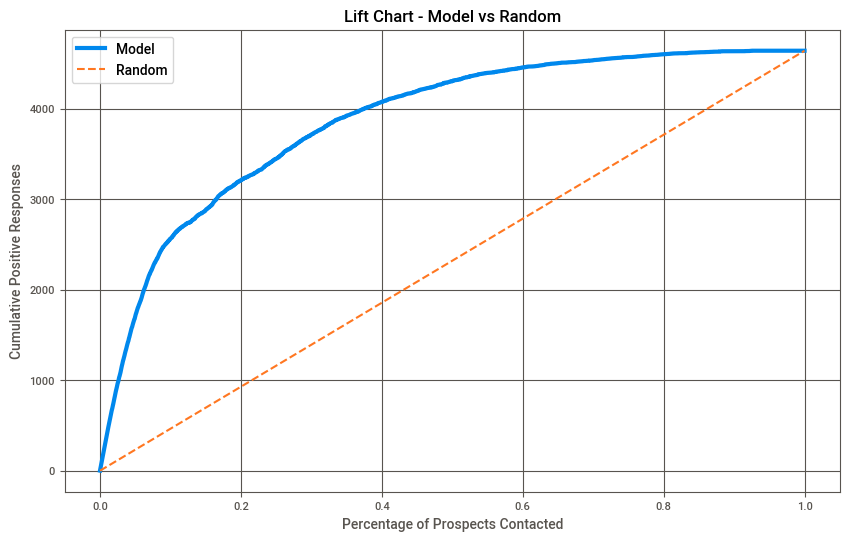

In [42]:
import matplotlib.pyplot as plt

df['prob_yes'] = rf.predict_proba(X)[:, 1]
df = df.sort_values('prob_yes', ascending=False).reset_index(drop=True)

# Cumulative gains
df['cumulative_yes'] = df['target'].cumsum()
df['cumulative_pct'] = df.index / len(df)
random_line = df['cumulative_pct'] * df['target'].sum()

plt.figure(figsize=(10, 6))
plt.plot(df['cumulative_pct'], df['cumulative_yes'], label='Model', linewidth=3)
plt.plot(df['cumulative_pct'], random_line, label='Random', linestyle='--')
plt.xlabel('Percentage of Prospects Contacted')
plt.ylabel('Cumulative Positive Responses')
plt.title('Lift Chart - Model vs Random')
plt.legend()
plt.grid(True)
plt.show()

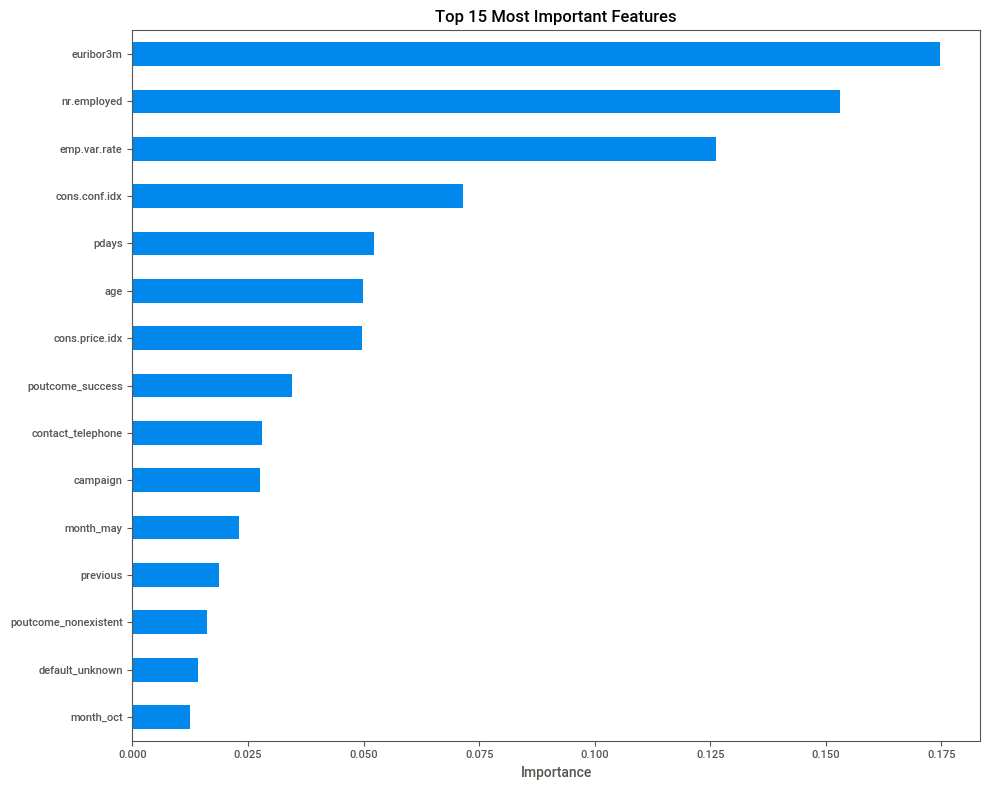

In [43]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.nlargest(15)

plt.figure(figsize=(10, 8))
top_features.sort_values().plot(kind='barh')
plt.title('Top 15 Most Important Features')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

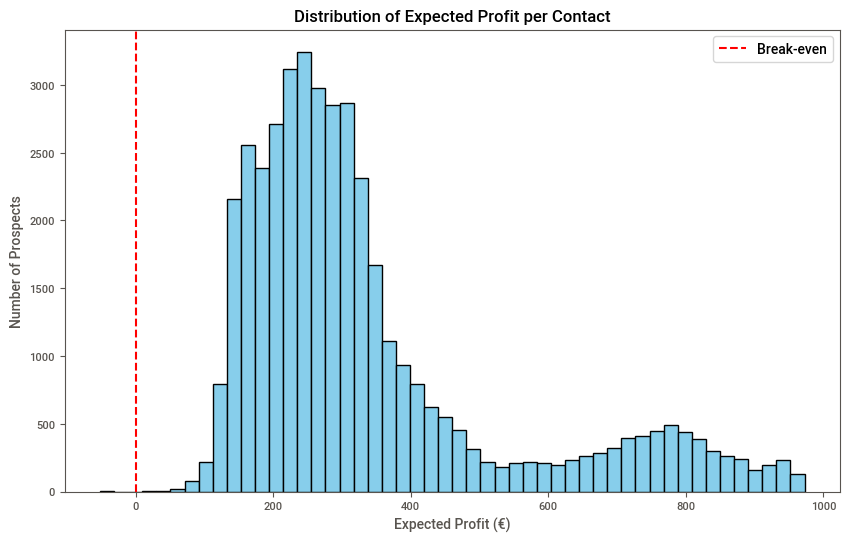

In [44]:
plt.figure(figsize=(10, 6))
plt.hist(df['expected_profit'], bins=50, color='skyblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Break-even')
plt.title('Distribution of Expected Profit per Contact')
plt.xlabel('Expected Profit (€)')
plt.ylabel('Number of Prospects')
plt.legend()
plt.show()


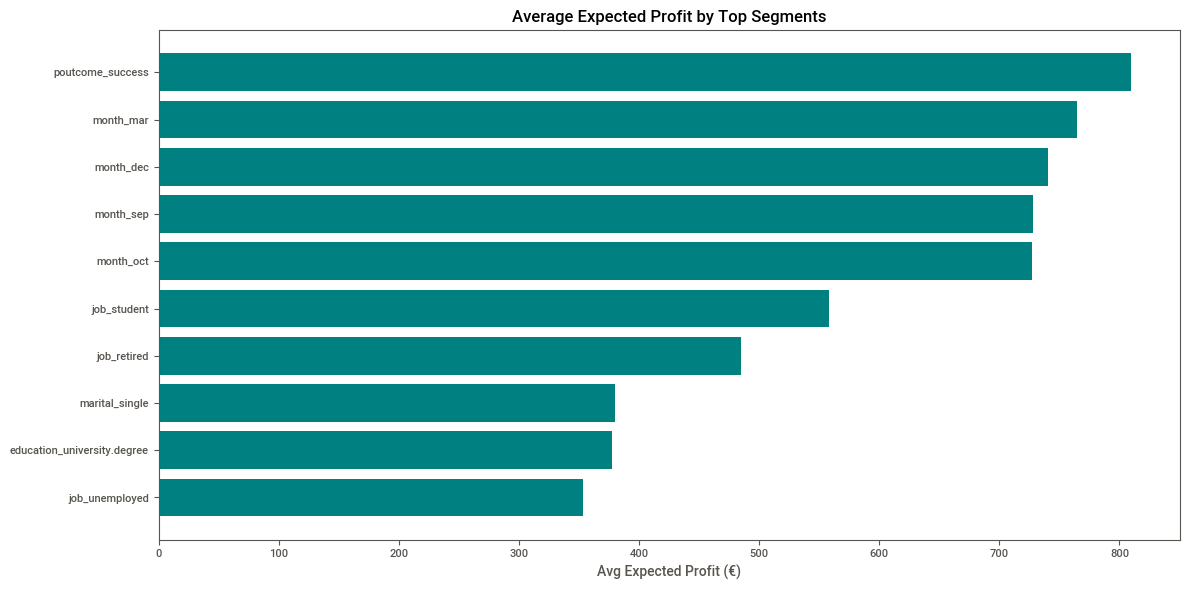

In [45]:
# Top segments profit bar chart
top_segments = top.head(10)  # from your earlier top segments code

plt.figure(figsize=(12, 6))
plt.barh(top_segments['segment'], top_segments['mean_profit'], color='teal')
plt.title('Average Expected Profit by Top Segments')
plt.xlabel('Avg Expected Profit (€)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

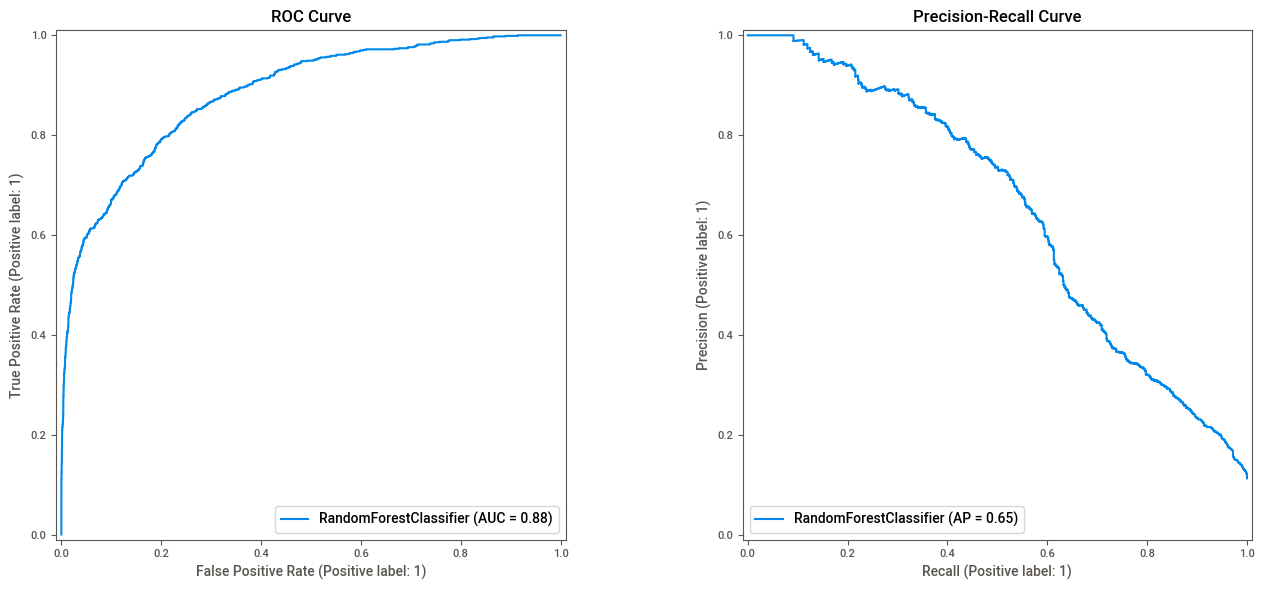

In [46]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax[0])
ax[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_estimator(rf, X_test, y_test, ax=ax[1])
ax[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()